# E1: Closeness Task (Forward Simulation) — Redesigned

**Research question:** Does including an NLE help an LLM judge correctly assess the model's prediction error magnitude?

## Design

Each test instance is evaluated under **5 information conditions**:

| Condition | Prediction+Features | SHAP (X) | Metrics (T) | NLE (E) |
|-----------|:--:|:--:|:--:|:--:|
| None | ✓ | ✗ | ✗ | ✗ |
| X | ✓ | ✓ | ✗ | ✗ |
| T | ✓ | ✗ | ✓ | ✗ |
| X+T | ✓ | ✓ | ✓ | ✗ |
| E+X+T | ✓ | ✓ | ✓ | ✓ |

**Why only E+X+T and not standalone E?** The NLE was generated with full context (SHAP values + metrics), so it narrates that information in prose. Showing E without X+T would leak X+T content through the narrative. The only clean NLE test is E+X+T vs X+T — same structured data, NLE adds narrative interpretation on top.

**2×2 generator×judge design:** For the E+X+T condition, both GPT-4o and DeepSeek-R1 NLEs are evaluated by both judges (4 combinations). No-NLE conditions have no generator dimension — just 2 judges each.

## Judgment count

- No-NLE conditions: 4 × N × 2 judges
- E+X+T condition: 1 × N × 2 generators × 2 judges
- **Pilot (N=15):** 4×15×2 + 1×15×2×2 = 120 + 60 = **180**
- **Full (N=60):** 4×60×2 + 1×60×2×2 = 480 + 240 = **720**

## Why this is different from old E1

Old E1 used 3 test instances × full Paper 1 factorial = 6,864 judgments. Mixed NLE quality levels, limited statistical power. Old results preserved in `Code/from_XAI_trustlab/results/E1_closeness/` as appendix robustness evidence.

## Statistical plan

- **Primary:** Accuracy (% correct error bucket) by condition
- **Key contrast:** X+T vs E+X+T (does NLE help on top of structured info?)
- **Secondary:** any-NLE vs no-NLE aggregated (Mann-Whitney U, Cohen's h)
- **Confidence × correctness:** Does NLE increase overconfidence?
- **95% CI:** Wilson interval
- **Pilot (N=15) → effect size → power check → Full (N=60)**

## 0. Setup

In [1]:
import os
import sys
import asyncio
import json
import re
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt

import utils

# ── Toggle: pilot vs full ──────────────────────────────────────────
PILOT_MODE = False   # Set False for full experiment
N = 15 if PILOT_MODE else 60
RANDOM_SEED = 42

# Override from run_all.py script
if os.environ.get('EXPERIMENT_N'):
    N = int(os.environ['EXPERIMENT_N'])
    PILOT_MODE = N < 60
# ───────────────────────────────────────────────────────────────────

RESULTS_DIR = utils.RESULTS_DIR / 'E1'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 5 information conditions
CONDITIONS = [
    {'name': 'Baseline', 'nle': False, 'xai': False, 'metrics': False},
    {'name': 'X',        'nle': False, 'xai': True,  'metrics': False},
    {'name': 'T',        'nle': False, 'xai': False, 'metrics': True},
    {'name': 'X+T',      'nle': False, 'xai': True,  'metrics': True},
    {'name': 'E+X+T',    'nle': True,  'xai': True,  'metrics': True},
]

VALID_BUCKETS = {'small', 'medium', 'large', 'very_large'}

mode_str = f'PILOT (N={N})' if PILOT_MODE else f'FULL (N={N})'
print(f'E1 Closeness Task — {mode_str}')
print(f'Conditions: {[c["name"] for c in CONDITIONS]}')

E1 Closeness Task — FULL (N=60)
Conditions: ['Baseline', 'X', 'T', 'X+T', 'E+X+T']


## 1. Load data

In [2]:
# Load test instances with SHAP values
model = utils.load_xgb_model()
test_df = utils.build_test_with_shap(model)
test_df['error_bucket'] = test_df['pct_error'].apply(utils.pct_error_to_bucket)

# Load NLE cache (120 rows: 60 × 2 generators)
nle_cache = utils.load_nle_cache()

print(f'Test instances: {len(test_df)}')
print(f'NLE cache: {len(nle_cache)} rows ({nle_cache["generator"].value_counts().to_dict()})')
print(f'Error bucket distribution:')
print(test_df['error_bucket'].value_counts())

# Sample N instances (stratified by error bucket)
if N < len(test_df):
    sampled_indices = []
    for bucket, group in test_df.groupby('error_bucket'):
        n_from_bucket = max(1, round(N * len(group) / len(test_df)))
        sampled_indices.extend(group.sample(min(len(group), n_from_bucket),
                                            random_state=RANDOM_SEED).index.tolist())
    if len(sampled_indices) < N:
        remaining = [i for i in test_df.index if i not in sampled_indices]
        extra = np.random.default_rng(RANDOM_SEED).choice(remaining, size=N - len(sampled_indices), replace=False)
        sampled_indices.extend(extra.tolist())
    sampled_indices = sampled_indices[:N]
    sample_df = test_df.loc[sampled_indices].copy()
else:
    sample_df = test_df.copy()

# orig_idx = original test set index = RowPos in nle_cache
sample_df['orig_idx'] = sample_df.index
sample_df = sample_df.reset_index(drop=True)

print(f'\nUsing {len(sample_df)} instances')
print('Sample bucket distribution:', sample_df['error_bucket'].value_counts().to_dict())
print('orig_idx values (RowPos):', sorted(sample_df['orig_idx'].tolist()))

Test instances: 60
NLE cache: 120 rows ({'gpt': 60, 'deepseek': 60})
Error bucket distribution:
error_bucket
medium        29
large         16
small         12
very_large     3
Name: count, dtype: int64

Using 60 instances
Sample bucket distribution: {'medium': 29, 'large': 16, 'small': 12, 'very_large': 3}
orig_idx values (RowPos): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]


In [3]:
# Error bucket distribution across ALL 60 test instances
print('=== Error bucket distribution (all 60 instances) ===')
print(test_df['error_bucket'].value_counts().sort_index())
print()
print(f'Signed PctError range: [{test_df["pct_error"].min():.1f}%, {test_df["pct_error"].max():.1f}%]')
print(f'Abs PctError range:    [{test_df["pct_error"].abs().min():.1f}%, {test_df["pct_error"].abs().max():.1f}%]')
print(f'Mean abs PctError:     {test_df["pct_error"].abs().mean():.1f}%')
print()
print(test_df.groupby('error_bucket')['pct_error'].agg(['min', 'max', 'mean', 'count']).round(1))

=== Error bucket distribution (all 60 instances) ===
error_bucket
large         16
medium        29
small         12
very_large     3
Name: count, dtype: int64

Signed PctError range: [-31.4%, 80.2%]
Abs PctError range:    [0.3%, 80.2%]
Mean abs PctError:     12.5%

               min   max  mean  count
error_bucket                         
large        -22.0  24.2  -1.8     16
medium       -12.7  14.7   0.7     29
small         -4.0   4.2   0.1     12
very_large   -31.4  80.2  32.9      3


## 2. Build judge prompts

In [4]:
JUDGE_SYSTEM = """You are evaluating a machine learning model's prediction accuracy for a time series forecasting task.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

Your task: Based on all the information provided, assess how large the prediction error is likely to be. Carefully evaluate the features, model context, and any additional information given to form your judgment.

Important: Think carefully about each specific instance. Consider all the details provided — feature values, patterns, and any explanations. Do not default to a "safe" middle-ground answer. The prediction has a specific error magnitude; use the evidence to determine what it is.

Evaluation steps (think through each before giving your final answer):
1. Examine the features — consider the lag values, the time of year (season in France), holidays, and whether the prediction seems reasonable given this context
2. Compare the prediction to recent lag values — does it follow the recent trend?
3. If model performance metrics are provided, use them to estimate a typical error range
4. If SHAP values are provided, consider whether each feature's contribution makes sense given the feature values and context
5. If a natural language explanation is provided, you can use it to better understand the model's reasoning
6. Weigh all available evidence to determine the most likely error magnitude

Error bucket definitions (based on absolute percentage error, regardless of whether the model over- or under-predicts):
- small: [0%, 5%) — absolute error less than 5%
- medium: [5%, 15%) — absolute error from 5% up to but not including 15%
- large: [15%, 30%) — absolute error from 15% up to but not including 30%
- very_large: [30%, +inf) — absolute error 30% or more

Confidence scale:
- 1 = Very uncertain about my assessment
- 2 = Somewhat uncertain
- 3 = Moderately confident
- 4 = Fairly confident
- 5 = Very certain about my assessment

You must respond with EXACTLY this JSON format and nothing else:
{
  "error_bucket": "<one of: small, medium, large, very_large>",
  "confidence": <integer from 1 to 5>,
  "reasoning": "<one sentence explaining your choice>"
}"""

DOMAIN_CONTEXT = """The following is about time series data with a single-step ahead prediction, where the model predicts the next value in the time series based on previous observations.
Data Domain: Energy Consumption
Dataset Description:
- The dataset contains 2,075,259 measurements from a house in Sceaux, France (near Paris), Dec 2006–Nov 2010.
- Recorded at one-minute resolution, then resampled weekly.
- Lag_1..Lag_7 (previous 7 weeks of consumption in kWh), ISO week number and number of public holidays per week were added as features.
- Target: weekly electricity consumption (kWh)."""


def build_prompt(row: pd.Series, condition: dict, nle_text: str = '') -> str:
    """Build the judge prompt for a given instance and condition."""
    parts = [DOMAIN_CONTEXT, '']

    # Always included: model name + prediction + features
    parts.append(f'Model Used: XGBRegressor')

    # Optional: Metrics bundle
    if condition['metrics']:
        parts.append(f'Model Performance:')
        parts.append(f'  - MAE: {utils.XGB_PERF["MAE"]:.3f}')
        parts.append(f'  - RMSE: {utils.XGB_PERF["RMSE"]:.3f}')
        parts.append(f'  - R²: {utils.XGB_PERF["R2"]:.3f}')

    parts.append(f'')
    parts.append(f'Prediction: {row["prediction"]:.2f}')
    parts.append(f'')
    parts.append(f'Instance Features or Context:')
    for f in utils.FEATURES:
        parts.append(f'{f}: {row[f]}')

    # Optional: XAI bundle (SHAP values)
    if condition['xai']:
        parts.append(f'')
        parts.append(f'SHAP values:')
        # Sort by absolute SHAP value descending (same as NLE generation prompt)
        shap_pairs = [(f, row[f'shap_{f}']) for f in utils.FEATURES]
        shap_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
        for feat, val in shap_pairs:
            parts.append(f'{feat}: {val:+.3f}')
        parts.append(f'The expected/base value for SHAP: {row["shap_base_value"]:.3f}')

    # Optional: NLE
    if condition['nle'] and nle_text:
        parts.append(f'')
        parts.append(f'Natural language explanation of this prediction:')
        parts.append(nle_text)

    parts.append(f'')
    parts.append(f'Based on all the information above, classify this prediction\'s likely error bucket.')

    return '\n'.join(parts)


# Preview prompts
row0 = sample_df.iloc[0]
orig_idx_0 = int(row0['orig_idx'])
print('=== SYSTEM PROMPT ===')
print(JUDGE_SYSTEM)
print()
print('=' * 60)
print('=== Baseline condition (human msg) ===')
print(build_prompt(row0, CONDITIONS[0]))
print()
print('=' * 60)
print('=== X+T condition (human msg) ===')
print(build_prompt(row0, CONDITIONS[3]))
print()
print('=' * 60)
print('=== E+X+T condition — GPT NLE (human msg) ===')
nle_gpt_0 = nle_cache[(nle_cache['RowPos'] == orig_idx_0) & (nle_cache['generator'] == 'gpt')]
nle_text_0 = nle_gpt_0.iloc[0]['Explanation'] if len(nle_gpt_0) else '(no NLE found)'
print(build_prompt(row0, CONDITIONS[4], nle_text_0))

=== SYSTEM PROMPT ===
You are evaluating a machine learning model's prediction accuracy for a time series forecasting task.
You have limited background in machine learning and statistics — you understand basic concepts but are not an expert.

Your task: Based on all the information provided, assess how large the prediction error is likely to be. Carefully evaluate the features, model context, and any additional information given to form your judgment.

Important: Think carefully about each specific instance. Consider all the details provided — feature values, patterns, and any explanations. Do not default to a "safe" middle-ground answer. The prediction has a specific error magnitude; use the evidence to determine what it is.

Evaluation steps (think through each before giving your final answer):
1. Examine the features — consider the lag values, the time of year (season in France), holidays, and whether the prediction seems reasonable given this context
2. Compare the prediction to re

## 3. Response parsing

In [5]:
def parse_response(raw: str) -> dict:
    """Parse judge response into {bucket, confidence, reasoning}."""
    # Try JSON extraction first
    match = re.search(r'\{[^{}]+\}', raw, re.DOTALL)
    if match:
        try:
            parsed = json.loads(match.group())
            bucket = parsed.get('error_bucket', '').lower().strip()
            if bucket in VALID_BUCKETS:
                conf = parsed.get('confidence')
                if conf is not None:
                    try:
                        conf = int(conf)
                    except (ValueError, TypeError):
                        conf = None
                return {
                    'bucket': bucket,
                    'confidence': conf,
                    'reasoning': parsed.get('reasoning', ''),
                }
        except json.JSONDecodeError:
            pass

    # Fallback: keyword extraction
    raw_lower = raw.lower()
    for kw in ['very_large', 'very large', 'large', 'medium', 'small']:
        if kw in raw_lower:
            return {'bucket': kw.replace(' ', '_'), 'confidence': None, 'reasoning': raw[:200]}

    return {'bucket': 'parse_error', 'confidence': None, 'reasoning': raw[:200]}

## 4. Run experiment

In [6]:
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')

# Resume support
if CACHE_PATH.exists():
    existing = pd.read_csv(CACHE_PATH)
    done_keys = set(zip(existing['instance_idx'].astype(str),
                        existing['condition'],
                        existing['generator'],
                        existing['judge']))
    results = existing.to_dict('records')
    print(f'Resuming: {len(results)} judgments already done.')
else:
    done_keys = set()
    results = []


# Build NLE lookup: {(RowPos, generator) -> Explanation}
nle_lookup = {}
for _, nle_row in nle_cache.iterrows():
    nle_lookup[(int(nle_row['RowPos']), nle_row['generator'])] = nle_row['Explanation']


async def judge_one(orig_idx: int, row: pd.Series, condition: dict,
                    generator: str, judge: str) -> dict:
    """Single judgment call."""
    nle_text = ''
    if condition['nle']:
        nle_text = nle_lookup.get((orig_idx, generator), '')

    human_msg = build_prompt(row, condition, nle_text)

    if judge == 'gpt':
        success, result, retries, latency, err = await utils.async_call_gpt(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=200
        )
    else:
        success, result, retries, latency, err = await utils.async_call_deepseek(
            JUDGE_SYSTEM, human_msg, temperature=0.0, max_tokens=500
        )

    raw = (result or {}).get('text', '') if success else f'ERROR: {err}'
    parsed = parse_response(raw) if success else {'bucket': 'error', 'confidence': None, 'reasoning': str(err)}

    true_bucket = utils.pct_error_to_bucket(row['pct_error'])

    return {
        'instance_idx': orig_idx,
        'condition': condition['name'],
        'generator': generator,
        'judge': judge,
        'has_nle': condition['nle'],
        'has_xai': condition['xai'],
        'has_metrics': condition['metrics'],
        'WeekEndDate': str(row['DateTime']),
        'Prediction': float(row['prediction']),
        'TrueValue': float(row['True_Value']),
        'PctError': float(row['pct_error']),
        'true_bucket': true_bucket,
        'predicted_bucket': parsed['bucket'],
        'correct': int(parsed['bucket'] == true_bucket),
        'confidence': parsed['confidence'],
        'reasoning': parsed['reasoning'],
        'raw_response': raw[:500],
        'system_msg': JUDGE_SYSTEM,
        'human_msg': human_msg,
        'Duration_s': round(latency, 2) if success else None,
        'retries': retries if success else None,
    }


# Build task list
tasks = []

for _, row in sample_df.iterrows():
    orig_idx = int(row['orig_idx'])
    for cond in CONDITIONS:
        if cond['nle']:
            # NLE condition: 2 generators × 2 judges = 4 calls
            for gen in ['gpt', 'deepseek']:
                for judge in ['gpt', 'deepseek']:
                    key = (str(orig_idx), cond['name'], gen, judge)
                    if key not in done_keys:
                        tasks.append(judge_one(orig_idx, row, cond, gen, judge))
        else:
            # No-NLE condition: no generator dimension, 2 judges
            for judge in ['gpt', 'deepseek']:
                key = (str(orig_idx), cond['name'], 'none', judge)
                if key not in done_keys:
                    tasks.append(judge_one(orig_idx, row, cond, 'none', judge))

print(f'Tasks to run: {len(tasks)}')
print(f'Already done:  {len(done_keys)}')

if tasks:
    desc = f'E1 {"Pilot" if PILOT_MODE else "Full"} ({len(tasks)} judgments)'
    new_results = await utils.run_async_tasks(tasks, desc=desc)
    results.extend(new_results)

    # Save immediately
    pd.DataFrame(results).to_csv(CACHE_PATH, index=False)
    print(f'Saved {len(results)} total judgments -> {CACHE_PATH}')
else:
    print('Nothing to run — all judgments cached.')

results_df = pd.DataFrame(results)
print(f'\nTotal judgments: {len(results_df)}')
print(results_df['condition'].value_counts())

Resuming: 720 judgments already done.
Tasks to run: 0
Already done:  720
Nothing to run — all judgments cached.

Total judgments: 720
condition
E+X+T       240
Baseline    120
X           120
T           120
X+T         120
Name: count, dtype: int64


## 5. Analysis

In [7]:
# Load results from file (can re-run analysis independently of experiment)
CACHE_PATH = RESULTS_DIR / ('pilot_results.csv' if PILOT_MODE else 'full_results.csv')
df_res = pd.read_csv(CACHE_PATH)
df_valid = df_res[df_res['predicted_bucket'].isin(VALID_BUCKETS)].copy()

print(f'Valid judgments: {len(df_valid)} / {len(df_res)} ({len(df_valid)/len(df_res):.1%})')
print(f'Conditions: {sorted(df_valid["condition"].unique())}')

# ── Accuracy by condition ──────────────────────────────────────────
acc = df_valid.groupby('condition')['correct'].agg(['mean', 'sum', 'count'])
acc.columns = ['accuracy', 'n_correct', 'n_total']

# Wilson CI
def wilson_ci(s, n, alpha=0.05):
    z = norm.ppf(1 - alpha/2)
    p = s / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - margin, center + margin

acc['ci_lo'] = [wilson_ci(row.n_correct, row.n_total)[0] for _, row in acc.iterrows()]
acc['ci_hi'] = [wilson_ci(row.n_correct, row.n_total)[1] for _, row in acc.iterrows()]

print('\n=== Accuracy by condition ===')
print(acc.round(3))

# ── Key contrast: X+T vs E+X+T ────────────────────────────────────
xt = df_valid[df_valid['condition'] == 'X+T']['correct']
ext = df_valid[df_valid['condition'] == 'E+X+T']['correct']

if len(xt) > 0 and len(ext) > 0:
    u_stat, p_val = stats.mannwhitneyu(ext, xt, alternative='two-sided')
    from statsmodels.stats.proportion import proportion_effectsize
    h = proportion_effectsize(ext.mean(), xt.mean())
    print(f'\n=== Key contrast: X+T vs E+X+T ===')
    print(f'  X+T accuracy:   {xt.mean():.3f} (n={len(xt)})')
    print(f'  E+X+T accuracy: {ext.mean():.3f} (n={len(ext)})')
    print(f'  Diff:           {ext.mean() - xt.mean():+.3f}')
    print(f'  Mann-Whitney U={u_stat:.0f}, p={p_val:.4f}')
    print(f'  Cohen\'s h = {h:.3f}')

# ── NLE vs no-NLE aggregate ────────────────────────────────────────
no_nle = df_valid[~df_valid['has_nle']]['correct']
with_nle = df_valid[df_valid['has_nle']]['correct']

if len(no_nle) > 0 and len(with_nle) > 0:
    u2, p2 = stats.mannwhitneyu(with_nle, no_nle, alternative='two-sided')
    h2 = proportion_effectsize(with_nle.mean(), no_nle.mean())
    print(f'\n=== NLE vs no-NLE (aggregate) ===')
    print(f'  No NLE:   {no_nle.mean():.3f} (n={len(no_nle)})')
    print(f'  With NLE: {with_nle.mean():.3f} (n={len(with_nle)})')
    print(f'  Diff:     {with_nle.mean() - no_nle.mean():+.3f}')
    print(f'  Mann-Whitney U={u2:.0f}, p={p2:.4f}')
    print(f'  Cohen\'s h = {h2:.3f}')

# ── Per-judge breakdown ────────────────────────────────────────────
print('\n=== Accuracy by condition × judge ===')
print(df_valid.groupby(['condition', 'judge'])['correct'].mean().unstack().round(3))

# ── Predicted bucket distribution (medium-bias check) ──────────────
print('\n=== Predicted bucket distribution by judge ===')
print(df_valid.groupby('judge')['predicted_bucket'].value_counts().unstack(fill_value=0))

Valid judgments: 626 / 720 (86.9%)
Conditions: ['Baseline', 'E+X+T', 'T', 'X', 'X+T']

=== Accuracy by condition ===
           accuracy  n_correct  n_total  ci_lo  ci_hi
condition                                            
Baseline      0.398         43      108  0.311  0.492
E+X+T         0.465         94      202  0.398  0.534
T             0.465         47      101  0.371  0.562
X             0.426         46      108  0.337  0.520
X+T           0.467         50      107  0.376  0.561

=== Key contrast: X+T vs E+X+T ===
  X+T accuracy:   0.467 (n=107)
  E+X+T accuracy: 0.465 (n=202)
  Diff:           -0.002
  Mann-Whitney U=10786, p=0.9747
  Cohen's h = -0.004

=== NLE vs no-NLE (aggregate) ===
  No NLE:   0.439 (n=424)
  With NLE: 0.465 (n=202)
  Diff:     +0.027
  Mann-Whitney U=43966, p=0.5309
  Cohen's h = 0.054

=== Accuracy by condition × judge ===
judge      deepseek    gpt
condition                 
Baseline      0.464  0.327
E+X+T         0.504  0.414
T             0.525 

In [8]:
if PILOT_MODE:
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize

    # ── Correct power analysis: instance-level, paired design ──────────
    # Unit of analysis = instance (not individual judgment)
    # For each instance, compute mean accuracy per condition (across judges/generators)

    instance_acc = df_valid.groupby(['instance_idx', 'condition'])['correct'].mean().reset_index()

    # Pivot to get one row per instance, one column per condition
    pivot = instance_acc.pivot(index='instance_idx', columns='condition', values='correct')

    print('=== Per-instance accuracy by condition (pilot, N=15) ===')
    print(pivot.describe().round(3))
    print()

    # Key contrast: X+T vs E+X+T (paired)
    if 'X+T' in pivot.columns and 'E+X+T' in pivot.columns:
        paired = pivot[['X+T', 'E+X+T']].dropna()
        diff = paired['E+X+T'] - paired['X+T']

        print(f'=== Key contrast: X+T vs E+X+T (paired, N={len(paired)} instances) ===')
        print(f'  Mean X+T accuracy per instance:   {paired["X+T"].mean():.3f}')
        print(f'  Mean E+X+T accuracy per instance: {paired["E+X+T"].mean():.3f}')
        print(f'  Mean paired difference:           {diff.mean():+.3f}')
        print(f'  Std of paired difference:         {diff.std():.3f}')

        # Cohen's d for paired samples
        if diff.std() > 0:
            d_paired = abs(diff.mean()) / diff.std()
        else:
            d_paired = 0.0
        print(f'  Cohen\'s d (paired):              {d_paired:.3f}')

        # Paired t-test
        from scipy.stats import ttest_rel
        t_stat, p_val = ttest_rel(paired['E+X+T'], paired['X+T'])
        print(f'  Paired t-test: t={t_stat:.3f}, p={p_val:.4f}')

        # Required N for paired design
        if d_paired > 0.01:
            from statsmodels.stats.power import TTestIndPower
            # For paired t-test, required N per group:
            n_req = TTestIndPower().solve_power(effect_size=d_paired, alpha=0.05, power=0.80)
            sufficient = 60 >= n_req
            print(f'\n  Required N instances (α=0.05, power=0.80): {n_req:.0f}')
            print(f'  N=60 is {"SUFFICIENT" if sufficient else "INSUFFICIENT"}')
        else:
            print(f'\n  Effect size too small for power calculation (d={d_paired:.4f})')
            print(f'  Interpretation: no meaningful accuracy difference detected.')

        # What effects CAN we detect with N=60?
        from statsmodels.stats.power import TTestIndPower
        detectable_d = TTestIndPower().solve_power(nobs1=60, alpha=0.05, power=0.80)
        print(f'\n  Minimum detectable effect with N=60 (α=0.05, power=0.80): d={detectable_d:.3f}')
        print(f'  → N=60 can detect medium effects (d≥0.5) but not the tiny pilot effect (d={d_paired:.3f})')

    # ── Also check NLE vs no-NLE on confidence (secondary outcome) ─────
    print(f'\n=== Confidence effect (secondary) ===')
    conf_by_nle = df_valid.groupby(['instance_idx', 'has_nle'])['confidence'].mean().reset_index()
    conf_pivot = conf_by_nle.pivot(index='instance_idx', columns='has_nle', values='confidence')
    if False in conf_pivot.columns and True in conf_pivot.columns:
        conf_paired = conf_pivot.dropna()
        conf_diff = conf_paired[True] - conf_paired[False]
        d_conf = abs(conf_diff.mean()) / conf_diff.std() if conf_diff.std() > 0 else 0
        print(f'  No NLE mean confidence:  {conf_paired[False].mean():.2f}')
        print(f'  With NLE mean confidence: {conf_paired[True].mean():.2f}')
        print(f'  Cohen\'s d (paired):      {d_conf:.3f}')
        if d_conf > 0.01:
            n_req_conf = TTestIndPower().solve_power(effect_size=d_conf, alpha=0.05, power=0.80)
            print(f'  Required N for confidence effect: {n_req_conf:.0f}')
            print(f'  N=60 is {"SUFFICIENT" if 60 >= n_req_conf else "INSUFFICIENT"}')

    print(f'\n→ To run full experiment: set PILOT_MODE = False and re-run.')
else:
    print('Full experiment mode — skipping power analysis (already done in pilot).')

Full experiment mode — skipping power analysis (already done in pilot).


## Statistical Analysis Notes (from pilot review + external consultation)

### Design Summary
- **Within-instance (repeated measures)**: each instance appears in all 5 conditions
- **Outcome**: binary (correct/incorrect bucket classification)
- **Unit of analysis**: instance (N=15 pilot, N=60 full), NOT individual judgments
- Judgments within an instance are NOT independent (same instance, same judges)

### Consensus from 4 independent LLM statisticians (GPT-4o, Gemini, Grok, DeepSeek-R1)

**1. Primary test: Mixed-effects logistic regression (GLMM), not ANOVA**
- `correct ~ condition + judge + (1 | instance)`
- Binary outcome → logistic link, not normal/Gaussian
- Instance as random intercept handles non-independence
- Judge and generator as fixed effects (only 2 levels each)
- ANOVA is inappropriate for binary outcomes (violates normality assumption)
- Simple fallback: aggregate per-instance accuracy, then paired Wilcoxon signed-rank or permutation test

**2. Power analysis approach**
- Pilot effect on accuracy is essentially zero (d ≈ 0.07)
- Do NOT power on the observed tiny effect — it would require N=3,500+
- Instead report: "N=60 provides 80% power to detect medium effects (d ≥ 0.5). We observed no accuracy difference, suggesting any true effect is too small to be practically meaningful."
- Minimum detectable effect with N=60: d ≈ 0.36
- The confidence effect IS detectable with N=60 (d ≈ 0.8+ from pilot)
- Gold standard: simulation-based power for the GLMM. Acceptable approximation: paired t-test on per-instance mean accuracy differences.

**3. Additional metrics needed (beyond raw accuracy)**
- **Confusion matrix**: exposes the medium-defaulting behavior
- **Balanced accuracy**: average per-class recall — punishes "always say medium"
- **Macro-F1**: similar, penalizes ignoring rare classes
- **Per-class recall**: especially for small/large/very_large
- **Mean absolute bucket distance**: ordinal distance from correct bucket (e.g., predicting "medium" when truth is "very_large" = 2 buckets off)

**4. Medium bias is both a limitation AND a finding**
- GPT says "medium" 92% of the time, DeepSeek 84%
- Raw accuracy ≈ base rate of medium bucket (47%)
- This means neither judge effectively uses the provided information to discriminate
- Publishable framing: "Despite rich structured and natural-language explanations, judges remained heavily biased toward the modal 'medium' bucket, resulting in accuracy that matched the base rate in all conditions."

**5. The real finding: overconfidence**
- NLE does not improve accuracy (flat ~47% across all conditions)
- NLE increases confidence (3.82 vs 3.44)
- NLE doubles overconfidence rate when wrong (75% vs 45%)
- Framing: "NLEs act as persuasive rather than informative signals — they increase subjective certainty without improving objective performance."

### For the full run (post-pilot)
- Run N=60 with same design
- Primary analysis: GLMM logistic for accuracy, linear mixed model for confidence
- Add confusion matrices, balanced accuracy, macro-F1
- Test overconfidence interaction: `confidence ~ condition * correctness + judge + (1|instance)`
- Report both the accuracy null and the confidence/overconfidence positive finding

## 6. Confidence analysis

In [9]:
conf_df = df_valid[df_valid['confidence'].notna()].copy()
conf_df['confidence'] = pd.to_numeric(conf_df['confidence'], errors='coerce')
conf_df = conf_df[conf_df['confidence'].notna()]

if len(conf_df) > 0:
    print('=== Mean confidence by condition × correctness ===')
    ct = conf_df.groupby(['condition', 'correct'])['confidence'].mean().unstack()
    ct.columns = ['Wrong', 'Correct']
    print(ct.round(2))

    # Overconfidence: wrong + confidence >= 4
    wrong = conf_df[conf_df['correct'] == 0]
    if len(wrong) > 0:
        overconf = wrong.groupby('has_nle')['confidence'].apply(lambda x: (x >= 4).mean())
        overconf.index = ['No NLE' if not v else 'With NLE' for v in overconf.index]
        print(f'\nOverconfidence rate (wrong + confidence >= 4):')
        print(overconf.round(3))

    # Mean confidence: NLE vs no-NLE
    print(f'\nMean confidence:')
    print(f'  No NLE:   {conf_df[~conf_df["has_nle"]]["confidence"].mean():.2f}')
    print(f'  With NLE: {conf_df[conf_df["has_nle"]]["confidence"].mean():.2f}')
else:
    print('No confidence data available.')

=== Mean confidence by condition × correctness ===
           Wrong  Correct
condition                
Baseline    3.46     3.14
E+X+T       3.90     3.94
T           3.48     3.53
X           3.49     3.30
X+T         3.82     3.80

Overconfidence rate (wrong + confidence >= 4):
No NLE      0.574
With NLE    0.898
Name: confidence, dtype: float64

Mean confidence:
  No NLE:   3.52
  With NLE: 3.92


## 7. Visualisation

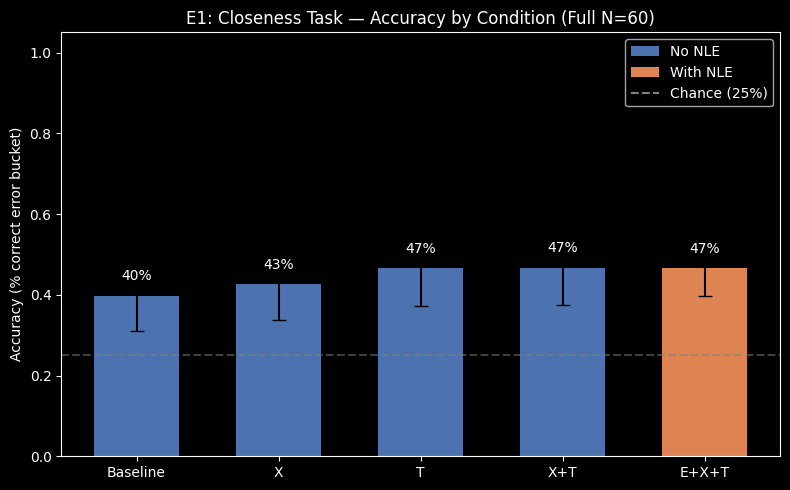

Figure saved: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E1/full_accuracy_by_condition.png


In [10]:
cond_order = ['Baseline', 'X', 'T', 'X+T', 'E+X+T']
colors = ['#4C72B0', '#4C72B0', '#4C72B0', '#4C72B0', '#DD8452']

accs = [acc.loc[c, 'accuracy'] if c in acc.index else 0 for c in cond_order]
lo = [acc.loc[c, 'ci_lo'] if c in acc.index else 0 for c in cond_order]
hi = [acc.loc[c, 'ci_hi'] if c in acc.index else 0 for c in cond_order]
errs = [[accs[i] - lo[i], hi[i] - accs[i]] for i in range(len(cond_order))]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cond_order, accs, color=colors, width=0.6,
              yerr=np.array(errs).T, capsize=5, ecolor='black')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy (% correct error bucket)')
mode_label = 'Pilot N=15' if PILOT_MODE else 'Full N=60'
ax.set_title(f'E1: Closeness Task — Accuracy by Condition ({mode_label})')
ax.axhline(0.25, ls='--', color='gray', alpha=0.5, label='Chance (25%)')

for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{a:.0%}', ha='center', va='bottom', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='No NLE'),
    Patch(facecolor='#DD8452', label='With NLE'),
    plt.Line2D([0], [0], color='gray', ls='--', label='Chance (25%)')
]
ax.legend(handles=legend_elements)
plt.tight_layout()

fig_path = RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_accuracy_by_condition.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print(f'Figure saved: {fig_path}')

## 8. Summary

In [11]:
# Save summary table
summary = acc.copy()
summary['ci'] = [f"[{row.ci_lo:.1%}, {row.ci_hi:.1%}]" for _, row in summary.iterrows()]
summary['has_nle'] = [c in ['E+X+T'] for c in summary.index]
summary.to_csv(RESULTS_DIR / f'{"pilot" if PILOT_MODE else "full"}_summary.csv')

print('=== E1 Summary ===')
print(summary[['accuracy', 'n_total', 'ci', 'has_nle']].round(3))
print()

if PILOT_MODE:
    print('NEXT: Review pilot results. If effect size is sufficient, set PILOT_MODE = False and re-run.')
else:
    print('Full experiment complete.')
    print(f'Results: {CACHE_PATH}')
    print(f'Summary: {RESULTS_DIR / "full_summary.csv"}')

=== E1 Summary ===
           accuracy  n_total              ci  has_nle
condition                                            
Baseline      0.398      108  [31.1%, 49.2%]    False
E+X+T         0.465      202  [39.8%, 53.4%]     True
T             0.465      101  [37.1%, 56.2%]    False
X             0.426      108  [33.7%, 52.0%]    False
X+T           0.467      107  [37.6%, 56.1%]    False

Full experiment complete.
Results: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E1/full_results.csv
Summary: /home/fabian/Desktop/Second_XAI_Paper/Code/new_experiments/results/E1/full_summary.csv
